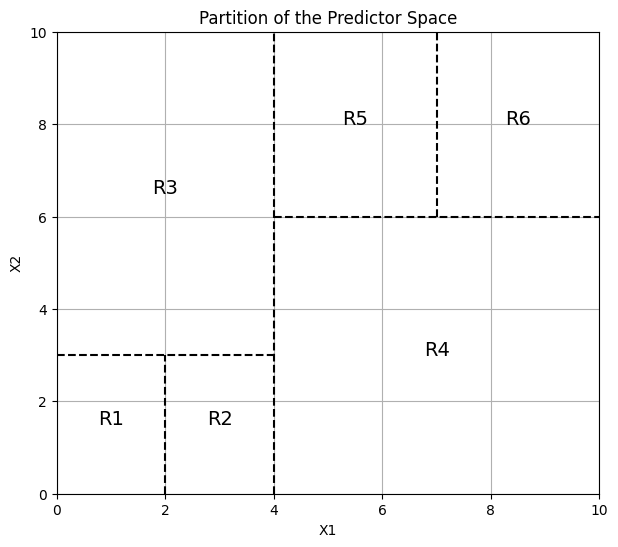

In [3]:
#Q1 ISLR page 363
import matplotlib.pyplot as plt

# Create figure for predictor space
plt.figure(figsize=(7, 6))

# Set axis limits
plt.xlim(0, 10)
plt.ylim(0, 10)

# Draw split lines
plt.axvline(x=4, color="black", linestyle="--")       # X1 < 4
plt.hlines(y=3, xmin=0, xmax=4, color="black", linestyle="--")  # X2 < 3
plt.vlines(x=2, ymin=0, ymax=3, color="black", linestyle="--")  # X1 < 2
plt.hlines(y=6, xmin=4, xmax=10, color="black", linestyle="--") # X2 < 6
plt.vlines(x=7, ymin=6, ymax=10, color="black", linestyle="--") # X1 < 7

# Label regions
plt.text(1, 1.5, "R1", fontsize=14, ha="center")
plt.text(3, 1.5, "R2", fontsize=14, ha="center")
plt.text(2, 6.5, "R3", fontsize=14, ha="center")
plt.text(7, 3, "R4", fontsize=14, ha="center")
plt.text(5.5, 8, "R5", fontsize=14, ha="center")
plt.text(8.5, 8, "R6", fontsize=14, ha="center")

# Axis labels and title
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Partition of the Predictor Space")

plt.grid(True)
plt.show()

In [4]:
from IPython.display import Markdown

Markdown("""
### Conceptual Question 1 Explanation

This partition is created using recursive binary splitting.

The first split is on **X1 < 4**.
The left side is split using **X2 < 3**.
The lower-left region is then split again using **X1 < 2**.

The right side of the original split is split using **X2 < 6**.
The upper-right region is split again using **X1 < 7**.

This produces six terminal regions: R1, R2, R3, R4, R5, and R6.
""")


### Conceptual Question 1 Explanation

This partition is created using recursive binary splitting.

The first split is on **X1 < 4**.  
The left side is split using **X2 < 3**.  
The lower-left region is then split again using **X1 < 2**.  

The right side of the original split is split using **X2 < 6**.  
The upper-right region is split again using **X1 < 7**.

This produces six terminal regions: R1, R2, R3, R4, R5, and R6.


In [5]:
print("""
                    X1 < 4?
                  /        \\
              Yes            No
             /                \\
        X2 < 3?              X2 < 6?
        /     \\              /      \\
     Yes       No         Yes        No
     /          \\          |          \\
 X1 < 2?        R3        R4        X1 < 7?
 /     \\                              /     \\
R1     R2                            R5     R6
""")


                    X1 < 4?
                  /        \
              Yes            No
             /                \
        X2 < 3?              X2 < 6?
        /     \              /      \
     Yes       No         Yes        No
     /          \          |          \
 X1 < 2?        R3        R4        X1 < 7?
 /     \                              /     \
R1     R2                            R5     R6



In [8]:
#Q12 page 366
!pip install ISLP

import numpy as np
import pandas as pd

from ISLP import load_data

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, log_loss

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.5 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=a1ee94268887125851378919cab74481c6d654f826be3c74d4354251b2476fbe
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [9]:
#load the dataset of my choice, weekly

Weekly = load_data("Weekly")

Weekly.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


In [10]:
#Inspect the weekly dataset
Weekly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Year       1089 non-null   int64   
 1   Lag1       1089 non-null   float64 
 2   Lag2       1089 non-null   float64 
 3   Lag3       1089 non-null   float64 
 4   Lag4       1089 non-null   float64 
 5   Lag5       1089 non-null   float64 
 6   Volume     1089 non-null   float64 
 7   Today      1089 non-null   float64 
 8   Direction  1089 non-null   category
dtypes: category(1), float64(7), int64(1)
memory usage: 69.4 KB


In [11]:
#The response variable of choice is Direction

X = Weekly.drop(columns=["Direction"])
y = Weekly["Direction"]

X.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178


In [12]:
#Split into train and test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [13]:
#Helper function to keep results organized

results = []

def evaluate_model(model_name, model, X_test, y_test):
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)

    accuracy = accuracy_score(y_test, predictions)
    error_rate = 1 - accuracy
    deviance = log_loss(y_test, probabilities)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Test Error Rate": error_rate,
        "Deviance / Log Loss": deviance
    })

    print(model_name)
    print("Accuracy:", accuracy)
    print("Test Error Rate:", error_rate)
    print("Deviance / Log Loss:", deviance)
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, predictions))
    print("\nClassification Report:")
    print(classification_report(y_test, predictions))

In [14]:
#Logistic regression
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

evaluate_model(
    "Logistic Regression",
    logistic_model,
    X_test,
    y_test
)

Logistic Regression
Accuracy: 0.9938837920489296
Test Error Rate: 0.006116207951070374
Deviance / Log Loss: 0.050799783188116225

Confusion Matrix:
[[143   2]
 [  0 182]]

Classification Report:
              precision    recall  f1-score   support

        Down       1.00      0.99      0.99       145
          Up       0.99      1.00      0.99       182

    accuracy                           0.99       327
   macro avg       0.99      0.99      0.99       327
weighted avg       0.99      0.99      0.99       327



In [15]:
# Bagging model
#Setting max_features=1.0 so each tree can use all predictors.

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

bagging_model.fit(X_train, y_train)

evaluate_model(
    "Bagging",
    bagging_model,
    X_test,
    y_test
)

Bagging
Accuracy: 1.0
Test Error Rate: 0.0
Deviance / Log Loss: 0.00017288928613148173

Confusion Matrix:
[[145   0]
 [  0 182]]

Classification Report:
              precision    recall  f1-score   support

        Down       1.00      1.00      1.00       145
          Up       1.00      1.00      1.00       182

    accuracy                           1.00       327
   macro avg       1.00      1.00      1.00       327
weighted avg       1.00      1.00      1.00       327



In [16]:
#random forest

random_forest_model = RandomForestClassifier(
    n_estimators=500,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

evaluate_model(
    "Random Forest",
    random_forest_model,
    X_test,
    y_test
)

Random Forest
Accuracy: 1.0
Test Error Rate: 0.0
Deviance / Log Loss: 0.048779352595168454

Confusion Matrix:
[[145   0]
 [  0 182]]

Classification Report:
              precision    recall  f1-score   support

        Down       1.00      1.00      1.00       145
          Up       1.00      1.00      1.00       182

    accuracy                           1.00       327
   macro avg       1.00      1.00      1.00       327
weighted avg       1.00      1.00      1.00       327



In [17]:
#Boosting

boosting_model = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=3,
    random_state=42
)

boosting_model.fit(X_train, y_train)

evaluate_model(
    "Boosting",
    boosting_model,
    X_test,
    y_test
)


Boosting
Accuracy: 1.0
Test Error Rate: 0.0
Deviance / Log Loss: 0.003320939527313061

Confusion Matrix:
[[145   0]
 [  0 182]]

Classification Report:
              precision    recall  f1-score   support

        Down       1.00      1.00      1.00       145
          Up       1.00      1.00      1.00       182

    accuracy                           1.00       327
   macro avg       1.00      1.00      1.00       327
weighted avg       1.00      1.00      1.00       327



In [23]:
#BART-style model
#The ISLP package includes BART mainly as a regression estimator
# We encoded Direction as 0/1 and classify using a 0.5 cutoff to create a classification approach

from ISLP.bart import BART   # ✅ no indentation

y_train_binary = y_train.map({"Down": 0, "Up": 1})
y_test_binary = y_test.map({"Down": 0, "Up": 1})

bart_model = BART(
    num_trees=50,
    random_state=42
)

bart_model.fit(X_train, y_train_binary)

bart_prob_up = bart_model.predict(X_test)
bart_prob_up = np.clip(bart_prob_up, 0, 1)

bart_predictions = np.where(bart_prob_up >= 0.5, "Up", "Down")

bart_accuracy = accuracy_score(y_test, bart_predictions)
bart_error = 1 - bart_accuracy

bart_probs = np.column_stack([1 - bart_prob_up, bart_prob_up])
bart_deviance = log_loss(y_test, bart_probs, labels=["Down", "Up"])

print("BART-style Classification")
print("Accuracy:", bart_accuracy)
print("Test Error Rate:", bart_error)
print("Deviance / Log Loss:", bart_deviance)


BART-style Classification
Accuracy: 0.9785932721712538
Test Error Rate: 0.021406727828746197
Deviance / Log Loss: 0.0578715912035725


In [24]:
#Compare all models
results_df = pd.DataFrame(results)

results_df.sort_values(by="Deviance / Log Loss")

,Model,Accuracy,Test Error Rate,Deviance / Log Loss
1,Bagging,1.000000,0.000000,0.000173
3,Boosting,1.000000,0.000000,0.003321
2,Random Forest,1.000000,0.000000,0.048779
0,Logistic Regression,0.993884,0.006116,0.050800


In [ ]:
#Feature importance for tree-based models
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_importance

In [25]:
boosting_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": boosting_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

boosting_importance

,Feature,Importance
7,Today,1.000000e+00
4,Lag4,1.452941e-15
2,Lag2,1.091231e-15
5,Lag5,9.109820e-16
3,Lag3,7.108236e-16
1,Lag1,6.677897e-16
6,Volume,3.680840e-16
0,Year,1.262818e-16


In [39]:
#Kaggle Competition
#Import libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, log_loss, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier


In [54]:
#Load the data

train = pd.read_csv("/content/train.csv")
kaggle_test = pd.read_csv("/content/test.csv")

train.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [56]:
#Separate features and target

target = "NObeyesdad"

X = train.drop(columns=[target])
y = train[target]

# Keep test IDs for Kaggle submission
test_ids = kaggle_test["id"]

# Remove id column from features
X = X.drop(columns=["id"])
X_kaggle = kaggle_test.drop(columns=["id"])

In [57]:
#Split training data into train and validation sets

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [58]:
#Preprocessing

categorical_features = X.select_dtypes(include=["object"]).columns
numerical_features = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [59]:
#Create models

models = {
    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=10,
            min_samples_split=10,
            random_state=42
        ))
    ]),

    "Bagging": Pipeline([
        ("preprocessor", preprocessor),
        ("model", BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=42),
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_split=5,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Boosting": Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ])
}

In [60]:
#Fit and evaluate each model

results = []

for model_name, model in models.items():

    # Fit model
    model.fit(X_train, y_train)

    # Predict on validation set
    valid_predictions = model.predict(X_valid)
    valid_probabilities = model.predict_proba(X_valid)

    # Calculate metrics
    accuracy = accuracy_score(y_valid, valid_predictions)
    test_error = 1 - accuracy
    deviance = log_loss(y_valid, valid_probabilities)

    # Save results
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Test Error Rate": test_error,
        "Deviance / Log Loss": deviance
    })

    print("=" * 60)
    print(model_name)
    print("Accuracy:", accuracy)
    print("Test Error Rate:", test_error)
    print("Deviance / Log Loss:", deviance)
    print()
    print(classification_report(y_valid, valid_predictions))

Decision Tree
Accuracy: 0.8763648041104688
Test Error Rate: 0.1236351958895312
Deviance / Log Loss: 1.1473190572160794

                     precision    recall  f1-score   support

Insufficient_Weight       0.90      0.92      0.91       757
      Normal_Weight       0.82      0.85      0.83       925
     Obesity_Type_I       0.86      0.85      0.85       873
    Obesity_Type_II       0.95      0.96      0.95       974
   Obesity_Type_III       1.00      0.99      0.99      1214
 Overweight_Level_I       0.75      0.71      0.73       728
Overweight_Level_II       0.78      0.77      0.77       757

           accuracy                           0.88      6228
          macro avg       0.86      0.86      0.86      6228
       weighted avg       0.88      0.88      0.88      6228

Bagging
Accuracy: 0.8937058445728966
Test Error Rate: 0.10629415542710341
Deviance / Log Loss: 0.4979496309038553

                     precision    recall  f1-score   support

Insufficient_Weight       0.9

In [61]:
#Compare model results

results_df = pd.DataFrame(results)

results_df.sort_values(by="Deviance / Log Loss")

,Model,Accuracy,Test Error Rate,Deviance / Log Loss
3,Boosting,0.902537,0.097463,0.287614
2,Random Forest,0.892903,0.107097,0.378109
1,Bagging,0.893706,0.106294,0.497950
0,Decision Tree,0.876365,0.123635,1.147319


In [62]:
#Create Kaggle submission files
for model_name, model in models.items():

    kaggle_predictions = model.predict(X_kaggle)

    submission = pd.DataFrame({
        "id": test_ids,
        "NObeyesdad": kaggle_predictions
    })

    file_name = model_name.lower().replace(" ", "_") + "_submission.csv"
    submission.to_csv(file_name, index=False)

    print(f"Saved: {file_name}")

Saved: decision_tree_submission.csv
Saved: bagging_submission.csv
Saved: random_forest_submission.csv
Saved: boosting_submission.csv
